<a href="https://colab.research.google.com/github/ryannemilligan/Predictive-Home-Maintenance-/blob/main/Predictive_Home_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn sqlalchemy streamlit matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 12.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

# Example synthetic data
np.random.seed(42)
data = {
    'HomeID': range(1, 501),
    'SquareFootage': np.random.randint(800, 4000, 500),
    'AgeOfHome': np.random.randint(1, 50, 500),
    'NumberOfAppliances': np.random.randint(3, 15, 500),
    'LastRepairDaysAgo': np.random.randint(0, 365, 500),
    'RepairType': np.random.choice(['Plumbing', 'Electrical', 'HVAC', 'Appliance'], 500),
    'RepairFrequency': np.random.choice(['High', 'Low'], 500)
}

df = pd.DataFrame(data)
df.head()

,HomeID,SquareFootage,AgeOfHome,NumberOfAppliances,LastRepairDaysAgo,RepairType,RepairFrequency
0,1,3974,48,6,68,Plumbing,High
1,2,1660,25,8,311,Appliance,Low
2,3,2094,40,4,288,Appliance,High
3,4,1930,45,10,249,Plumbing,Low
4,5,1895,1,10,35,HVAC,Low


In [3]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///home_maintenance.db')
df.to_sql('repairs', engine, index=False, if_exists='replace')

# Query it back
df_sql = pd.read_sql("SELECT * FROM repairs", engine)
df_sql.head()

,HomeID,SquareFootage,AgeOfHome,NumberOfAppliances,LastRepairDaysAgo,RepairType,RepairFrequency
0,1,3974,48,6,68,Plumbing,High
1,2,1660,25,8,311,Appliance,Low
2,3,2094,40,4,288,Appliance,High
3,4,1930,45,10,249,Plumbing,Low
4,5,1895,1,10,35,HVAC,Low


In [5]:
# 1. Prepare your data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features and target
X = df.drop('RepairFrequency', axis=1)
y = df['RepairFrequency']

# Identify categorical columns
categorical_features = ['RepairType']
numeric_features = ['SquareFootage', 'AgeOfHome', 'NumberOfAppliances', 'LastRepairDaysAgo']

# One-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features)
    ], remainder='passthrough'
)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create pipeline with preprocessing + model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4. Train model
model_pipeline.fit(X_train, y_train)

# 5. Test model
y_pred = model_pipeline.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.44      0.31      0.36        45
         Low       0.54      0.67      0.60        55

    accuracy                           0.51       100
   macro avg       0.49      0.49      0.48       100
weighted avg       0.50      0.51      0.49       100



In [6]:
import joblib

joblib.dump(model_pipeline, 'maintenance_model.pkl')

['maintenance_model.pkl']

In [7]:
model = joblib.load('maintenance_model.pkl')
predictions = model.predict(df_sql)
alerts = df_sql[predictions == 'High']
alerts.head()

,HomeID,SquareFootage,AgeOfHome,NumberOfAppliances,LastRepairDaysAgo,RepairType,RepairFrequency
0,1,3974,48,6,68,Plumbing,High
5,6,3892,16,3,238,HVAC,High
6,7,2438,39,14,147,Appliance,High
7,8,2969,5,5,226,Electrical,High
9,10,2038,29,11,336,HVAC,High


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of High vs Low repair risk
risk_counts = df['RepairFrequency'].value_counts()
print(risk_counts)

RepairFrequency
Low     263
High    237
Name: count, dtype: int64


/tmp/ipykernel_146/586352261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette="viridis")


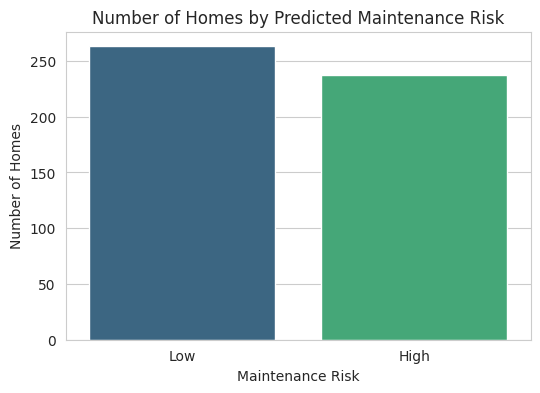

In [9]:
# Set style
sns.set_style("whitegrid")

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette="viridis")
plt.title("Number of Homes by Predicted Maintenance Risk")
plt.xlabel("Maintenance Risk")
plt.ylabel("Number of Homes")
plt.show()

In [10]:
high_risk = df[df['RepairFrequency'] == 'High']
low_risk = df[df['RepairFrequency'] == 'Low']

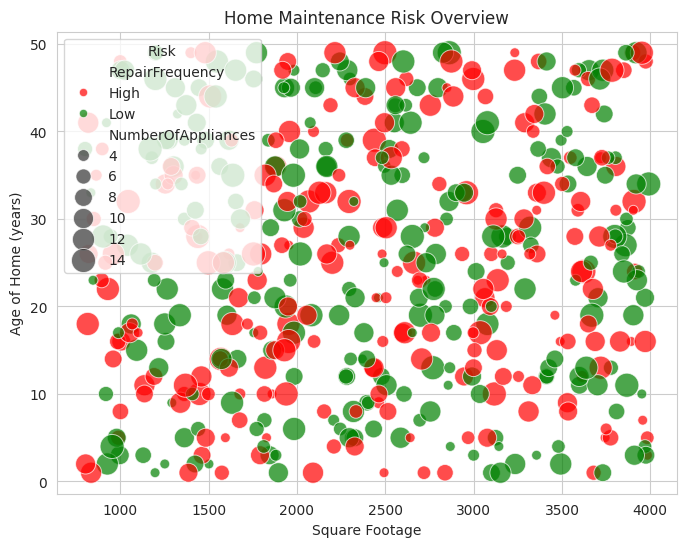

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='SquareFootage',
    y='AgeOfHome',
    hue='RepairFrequency',
    size='NumberOfAppliances',  # larger marker = more appliances
    sizes=(50, 300),
    palette={'High':'red', 'Low':'green'},
    alpha=0.7
)

plt.title('Home Maintenance Risk Overview')
plt.xlabel('Square Footage')
plt.ylabel('Age of Home (years)')
plt.legend(title='Risk')
plt.show()

/tmp/ipykernel_146/1424409619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


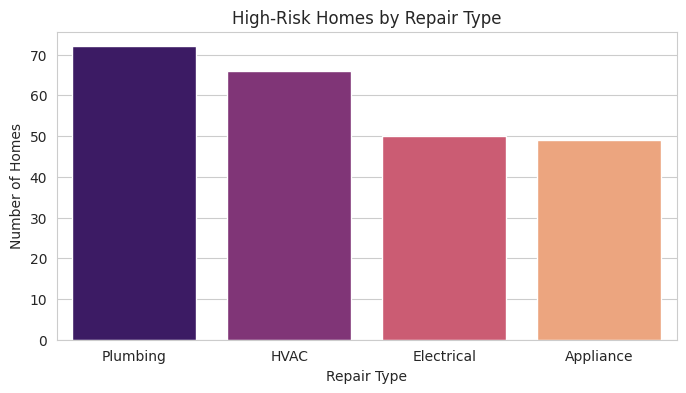

In [12]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=high_risk,
    x='RepairType',
    palette='magma',
    order=high_risk['RepairType'].value_counts().index
)
plt.title('High-Risk Homes by Repair Type')
plt.xlabel('Repair Type')
plt.ylabel('Number of Homes')
plt.show()